# Project 02: World Happiness Report 2023

Полиномиальная регрессия и классификация стран с высоким уровнем счастья.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge, RidgeCV
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, mean_absolute_error, mean_squared_error, precision_score, r2_score, recall_score, roc_auc_score, RocCurveDisplay
from sklearn.model_selection import KFold, StratifiedKFold, cross_val_predict, cross_val_score, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

pd.set_option("display.max_columns", 80)
pd.set_option("display.precision", 4)
plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
data_path = Path("data/WHR2023.csv")
raw_data = pd.read_csv(data_path)
selected_columns = [
    "Country name",
    "Ladder score",
    "Logged GDP per capita",
    "Social support",
    "Healthy life expectancy",
    "Freedom to make life choices",
    "Generosity",
    "Perceptions of corruption",
]

data = raw_data[selected_columns].copy()
data.columns = [
    "country",
    "ladder_score",
    "logged_gdp_per_capita",
    "social_support",
    "healthy_life_expectancy",
    "freedom_to_make_life_choices",
    "generosity",
    "perceptions_of_corruption",
]

data = data.dropna().copy()
data.head()

,country,ladder_score,logged_gdp_per_capita,social_support,healthy_life_expectancy,freedom_to_make_life_choices,generosity,perceptions_of_corruption
0,Finland,7.804,10.792,0.969,71.150,0.961,-0.019,0.182
1,Denmark,7.586,10.962,0.954,71.250,0.934,0.134,0.196
2,Iceland,7.530,10.896,0.983,72.050,0.936,0.211,0.668
3,Israel,7.473,10.639,0.943,72.697,0.809,-0.023,0.708
4,Netherlands,7.403,10.942,0.930,71.550,0.887,0.213,0.379


In [3]:
feature_names = [column for column in data.columns if column not in ["country", "ladder_score"]]
x = data[feature_names]
y = data["ladder_score"]

summary_table = data[["ladder_score"] + feature_names].describe().T
summary_table

,count,mean,std,min,25%,50%,75%,max
ladder_score,136.0,5.5444,1.1428,1.859,4.7025,5.6935,6.3425,7.804
logged_gdp_per_capita,136.0,9.4552,1.2101,5.527,8.5872,9.5745,10.5403,11.660
social_support,136.0,0.7986,0.1296,0.341,0.7210,0.8265,0.8960,0.983
healthy_life_expectancy,136.0,64.9676,5.7504,51.530,60.6485,65.8375,69.4125,77.280
freedom_to_make_life_choices,136.0,0.7881,0.1125,0.382,0.7262,0.8010,0.8748,0.961
generosity,136.0,0.0236,0.1416,-0.254,-0.0710,0.0020,0.1175,0.531
perceptions_of_corruption,136.0,0.7246,0.1774,0.146,0.6660,0.7725,0.8460,0.929


## Полиномиальная регрессия

In [4]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

polynomial_rows = []
for degree in range(1, 7):
    model = make_pipeline(
        StandardScaler(),
        PolynomialFeatures(degree=degree, include_bias=False),
        Ridge(alpha=1.0),
    )
    model.fit(x_train, y_train)
    train_prediction = model.predict(x_train)
    test_prediction = model.predict(x_test)
    polynomial_rows.append(
        {
            "degree": degree,
            "train_r2": r2_score(y_train, train_prediction),
            "test_r2": r2_score(y_test, test_prediction),
            "train_rmse": mean_squared_error(y_train, train_prediction) ** 0.5,
            "test_rmse": mean_squared_error(y_test, test_prediction) ** 0.5,
            "test_mae": mean_absolute_error(y_test, test_prediction),
        }
    )

polynomial_comparison = pd.DataFrame(polynomial_rows)
polynomial_comparison

,degree,train_r2,test_r2,train_rmse,test_rmse,test_mae
0,1,0.8087,0.8663,0.4997,0.4083,0.3141
1,2,0.8702,0.8196,0.4116,0.4744,0.3630
2,3,0.9567,0.6440,0.2378,0.6664,0.4514
3,4,0.9814,0.1550,0.1560,1.0267,0.7151
4,5,0.9853,-0.4954,0.1387,1.3658,0.7364
5,6,0.9873,-2.8752,0.1288,2.1986,1.1928


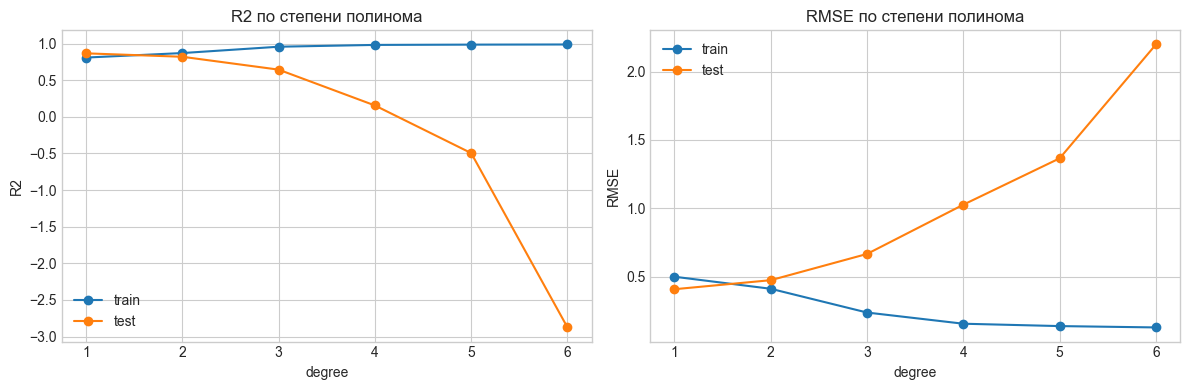

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(polynomial_comparison["degree"], polynomial_comparison["train_r2"], marker="o", label="train")
axes[0].plot(polynomial_comparison["degree"], polynomial_comparison["test_r2"], marker="o", label="test")
axes[0].set_title("R2 по степени полинома")
axes[0].set_xlabel("degree")
axes[0].set_ylabel("R2")
axes[0].legend()

axes[1].plot(polynomial_comparison["degree"], polynomial_comparison["train_rmse"], marker="o", label="train")
axes[1].plot(polynomial_comparison["degree"], polynomial_comparison["test_rmse"], marker="o", label="test")
axes[1].set_title("RMSE по степени полинома")
axes[1].set_xlabel("degree")
axes[1].set_ylabel("RMSE")
axes[1].legend()

plt.tight_layout()

In [6]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_rows = []
for degree in range(1, 6):
    model = make_pipeline(
        StandardScaler(),
        PolynomialFeatures(degree=degree, include_bias=False),
        RidgeCV(alphas=np.logspace(-3, 3, 40)),
    )
    predicted = cross_val_predict(model, x, y, cv=cv)
    cv_rows.append(
        {
            "degree": degree,
            "cv_r2": r2_score(y, predicted),
            "cv_rmse": mean_squared_error(y, predicted) ** 0.5,
            "cv_mae": mean_absolute_error(y, predicted),
        }
    )

polynomial_cv_comparison = pd.DataFrame(cv_rows).sort_values("cv_rmse")
polynomial_cv_comparison

,degree,cv_r2,cv_rmse,cv_mae
0,1,0.8129,0.4925,0.3764
1,2,0.7701,0.5460,0.4038
2,3,0.5514,0.7626,0.4744
3,4,0.4615,0.8356,0.5277
4,5,-0.6140,1.4465,0.7442


In [7]:
best_degree = int(polynomial_cv_comparison.iloc[0]["degree"])
best_regression_model = make_pipeline(
    StandardScaler(),
    PolynomialFeatures(degree=best_degree, include_bias=False),
    RidgeCV(alphas=np.logspace(-3, 3, 40)),
)
best_regression_model.fit(x, y)
regression_prediction = best_regression_model.predict(x)

regression_result_table = data[["country", "ladder_score"]].copy()
regression_result_table["predicted_ladder_score"] = regression_prediction
regression_result_table["absolute_error"] = (regression_result_table["ladder_score"] - regression_result_table["predicted_ladder_score"]).abs()
regression_result_table.sort_values("absolute_error", ascending=False).head(15)

,country,ladder_score,predicted_ladder_score,absolute_error
131,Botswana,3.435,4.9124,1.4774
135,Lebanon,2.392,3.7941,1.4021
111,Sri Lanka,4.442,5.6295,1.1875
128,Tanzania,3.694,4.8507,1.1567
122,Jordan,4.120,5.2691,1.1491
85,Congo (Brazzaville),5.267,4.2437,1.0233
120,Egypt,4.170,5.1782,1.0082
114,Cambodia,4.393,5.3761,0.9831
90,Guinea,5.072,4.1000,0.9720
133,Zimbabwe,3.204,4.1568,0.9528


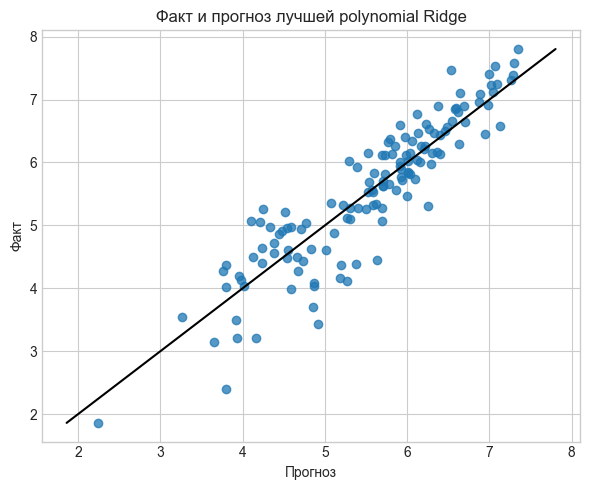

In [8]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(regression_prediction, y, alpha=0.75)
ax.plot([y.min(), y.max()], [y.min(), y.max()], color="black")
ax.set_title("Факт и прогноз лучшей polynomial Ridge")
ax.set_xlabel("Прогноз")
ax.set_ylabel("Факт")
plt.tight_layout()

## Бинарная классификация

In [9]:
third_quartile = data["ladder_score"].quantile(0.75)
data["high_happiness"] = (data["ladder_score"] > third_quartile).astype(int)

class_balance = data["high_happiness"].value_counts().sort_index().to_frame("countries")
class_balance["share"] = class_balance["countries"] / len(data)
class_balance

,countries,share
high_happiness,,
0,102,0.75
1,34,0.25


In [10]:
x_classification = data[feature_names]
y_classification = data["high_happiness"]

x_train, x_test, y_train, y_test = train_test_split(
    x_classification,
    y_classification,
    test_size=0.3,
    random_state=42,
    stratify=y_classification,
)

logistic_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=5000, C=1.0, solver="lbfgs"),
)
logistic_model.fit(x_train, y_train)

train_probability = logistic_model.predict_proba(x_train)[:, 1]
test_probability = logistic_model.predict_proba(x_test)[:, 1]
train_prediction = (train_probability >= 0.5).astype(int)
test_prediction = (test_probability >= 0.5).astype(int)

classification_metrics = pd.DataFrame(
    [
        {
            "sample": "train",
            "accuracy": accuracy_score(y_train, train_prediction),
            "precision": precision_score(y_train, train_prediction),
            "recall": recall_score(y_train, train_prediction),
            "f1": f1_score(y_train, train_prediction),
            "roc_auc": roc_auc_score(y_train, train_probability),
        },
        {
            "sample": "test",
            "accuracy": accuracy_score(y_test, test_prediction),
            "precision": precision_score(y_test, test_prediction),
            "recall": recall_score(y_test, test_prediction),
            "f1": f1_score(y_test, test_prediction),
            "roc_auc": roc_auc_score(y_test, test_probability),
        },
    ]
)
classification_metrics

,sample,accuracy,precision,recall,f1,roc_auc
0,train,0.9053,0.8571,0.75,0.8000,0.9572
1,test,0.9756,0.9091,1.00,0.9524,0.9903


In [11]:
confusion = pd.DataFrame(
    confusion_matrix(y_test, test_prediction),
    index=["actual_0", "actual_1"],
    columns=["predicted_0", "predicted_1"],
)
confusion

,predicted_0,predicted_1
actual_0,30,1
actual_1,0,10


In [12]:
logistic_step = logistic_model.named_steps["logisticregression"]
coefficient_table = pd.DataFrame(
    {
        "feature": feature_names,
        "coefficient": logistic_step.coef_[0],
        "odds_ratio": np.exp(logistic_step.coef_[0]),
    }
).sort_values("coefficient")
coefficient_table

,feature,coefficient,odds_ratio
5,perceptions_of_corruption,-0.4193,0.6575
4,generosity,0.1696,1.1849
2,healthy_life_expectancy,0.4467,1.5632
3,freedom_to_make_life_choices,0.9626,2.6184
1,social_support,1.2506,3.4923
0,logged_gdp_per_capita,1.6878,5.4077


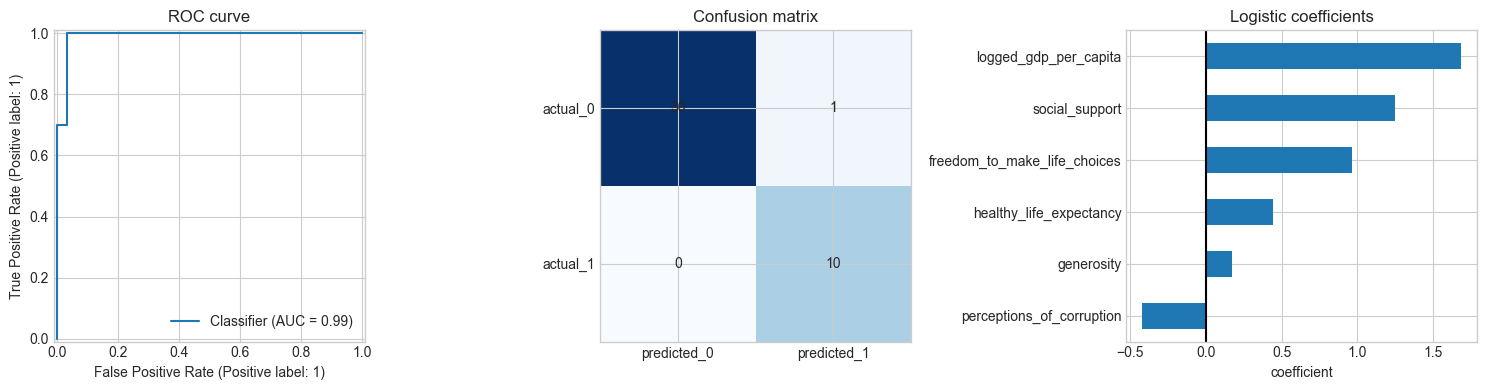

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

RocCurveDisplay.from_predictions(y_test, test_probability, ax=axes[0])
axes[0].set_title("ROC curve")

axes[1].imshow(confusion, cmap="Blues")
axes[1].set_xticks([0, 1])
axes[1].set_yticks([0, 1])
axes[1].set_xticklabels(confusion.columns)
axes[1].set_yticklabels(confusion.index)
for row in range(confusion.shape[0]):
    for column in range(confusion.shape[1]):
        axes[1].text(column, row, confusion.iloc[row, column], ha="center", va="center")
axes[1].set_title("Confusion matrix")

coefficient_table.plot(x="feature", y="coefficient", kind="barh", ax=axes[2], legend=False)
axes[2].axvline(0, color="black")
axes[2].set_title("Logistic coefficients")
axes[2].set_xlabel("coefficient")
axes[2].set_ylabel("")

plt.tight_layout()

In [14]:
classification_result_table = data[["country", "ladder_score", "high_happiness"]].copy()
classification_result_table["predicted_probability"] = logistic_model.predict_proba(x_classification)[:, 1]
classification_result_table["predicted_class"] = (classification_result_table["predicted_probability"] >= 0.5).astype(int)
classification_result_table.sort_values("predicted_probability", ascending=False).head(20)

,country,ladder_score,high_happiness,predicted_probability,predicted_class
1,Denmark,7.586,1,0.9775,1
6,Norway,7.315,1,0.9772,1
0,Finland,7.804,1,0.9770,1
5,Sweden,7.395,1,0.9766,1
24,Singapore,6.587,1,0.9739,1
8,Luxembourg,7.228,1,0.9662,1
7,Switzerland,7.240,1,0.9597,1
13,Ireland,6.911,1,0.9568,1
2,Iceland,7.530,1,0.9507,1
4,Netherlands,7.403,1,0.9413,1


## Вывод

Полиномиальные признаки быстро дают переобучение, поэтому качество надо смотреть на тесте и кросс-валидации. Для бинаризации по верхнему квартилю логистическая регрессия хорошо отделяет страны с высоким уровнем счастья; главные положительные факторы совпадают с линейной задачей.